In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv("../data/donnees_employes.csv")


![](../../imgs/featureEngin.png)

In [ ]:
df.head() # display the first 5 rows of the dataframe

,ID_Emp,Dep_name,Age,Gender,Edu_level,Exp_years,Annual_income,Week_WoekHours,Performance_Score,Work_satisfaction,Home_distance_km,Leaves_days,Project_finished,Training_hours,Bonus_year,Hiring_Date,Seniority_years,Wage_hour
0,1,Marketing,43,H,Master,8,114178,36.6,2,4,85,23,10,43,1667,2022-10-05,2.2,59.99
1,2,Finance,42,F,Licence,24,41094,34.9,5,5,16,17,12,8,909,2017-03-05,7.8,22.64
2,3,Ventes,27,H,Master,28,117959,37.8,2,1,9,20,1,66,8467,2021-10-15,3.1,60.01
3,4,Finance,27,F,Bac,24,63418,39.4,3,1,13,26,7,53,9083,2019-03-04,5.8,30.95
4,5,Finance,25,F,Bac,27,35741,43.3,2,2,28,21,17,25,8204,2017-01-30,7.8,15.87


In [1]:
df.info() # display dT types 

NameError: name 'df' is not defined

# Nettoyage des données

#### Vérification des valeurs manquantes

In [129]:
print(df.isnull().sum())

ID_Employe              0
Nom_Departement         0
Age                     0
Genre                   0
Niveau_Education        0
Annees_Experience       0
Salaire_Annuel          0
Heures_Travail_Hebdo    0
Performance_Score       0
Satisfaction_Travail    0
Distance_Domicile_km    0
Jours_Conges_Pris       0
Projets_Completes       0
Formation_Heures        0
Bonus_Annuel            0
Date_Embauche           0
Anciennete_Annees       0
Salaire_Horaire         0
dtype: int64


In [130]:
df.duplicated().sum()

np.int64(0)

#### suppression le column ID_Employe

In [131]:
df.drop(columns=["ID_Employe"], inplace=True)
df.drop(columns=["Date_Embauche"], inplace=True)

#### valeurs aberrants

In [132]:
from sklearn.preprocessing import StandardScaler
def normalize_and_remove_outliers(df, columns, z_threshold=3):
    # Create a copy of the DataFrame to avoid modifying the original
    df_cleaned = df.copy()

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Normalize the numerical columns
    normalized_data = scaler.fit_transform(df[columns])
    normalized_df = pd.DataFrame(normalized_data, columns=columns, index=df.index)

    # Identify outliers (where absolute Z-score > threshold)
    outlier_mask = (normalized_df.abs() > z_threshold).any(axis=1)

    # Remove outliers from the original DataFrame
    df_cleaned = df_cleaned.loc[~outlier_mask]

    # Replace original numerical columns with normalized values
    df_cleaned[columns] = normalized_df.loc[~outlier_mask]

    return df_cleaned

In [133]:

# Apply the function to your DataFrame
numerical_cols = df.select_dtypes('number').columns
df = normalize_and_remove_outliers(df, numerical_cols, z_threshold=3)

In [134]:

df.shape

(997, 16)

In [135]:
#outliers.any(axis=1)

### Visualisation des données

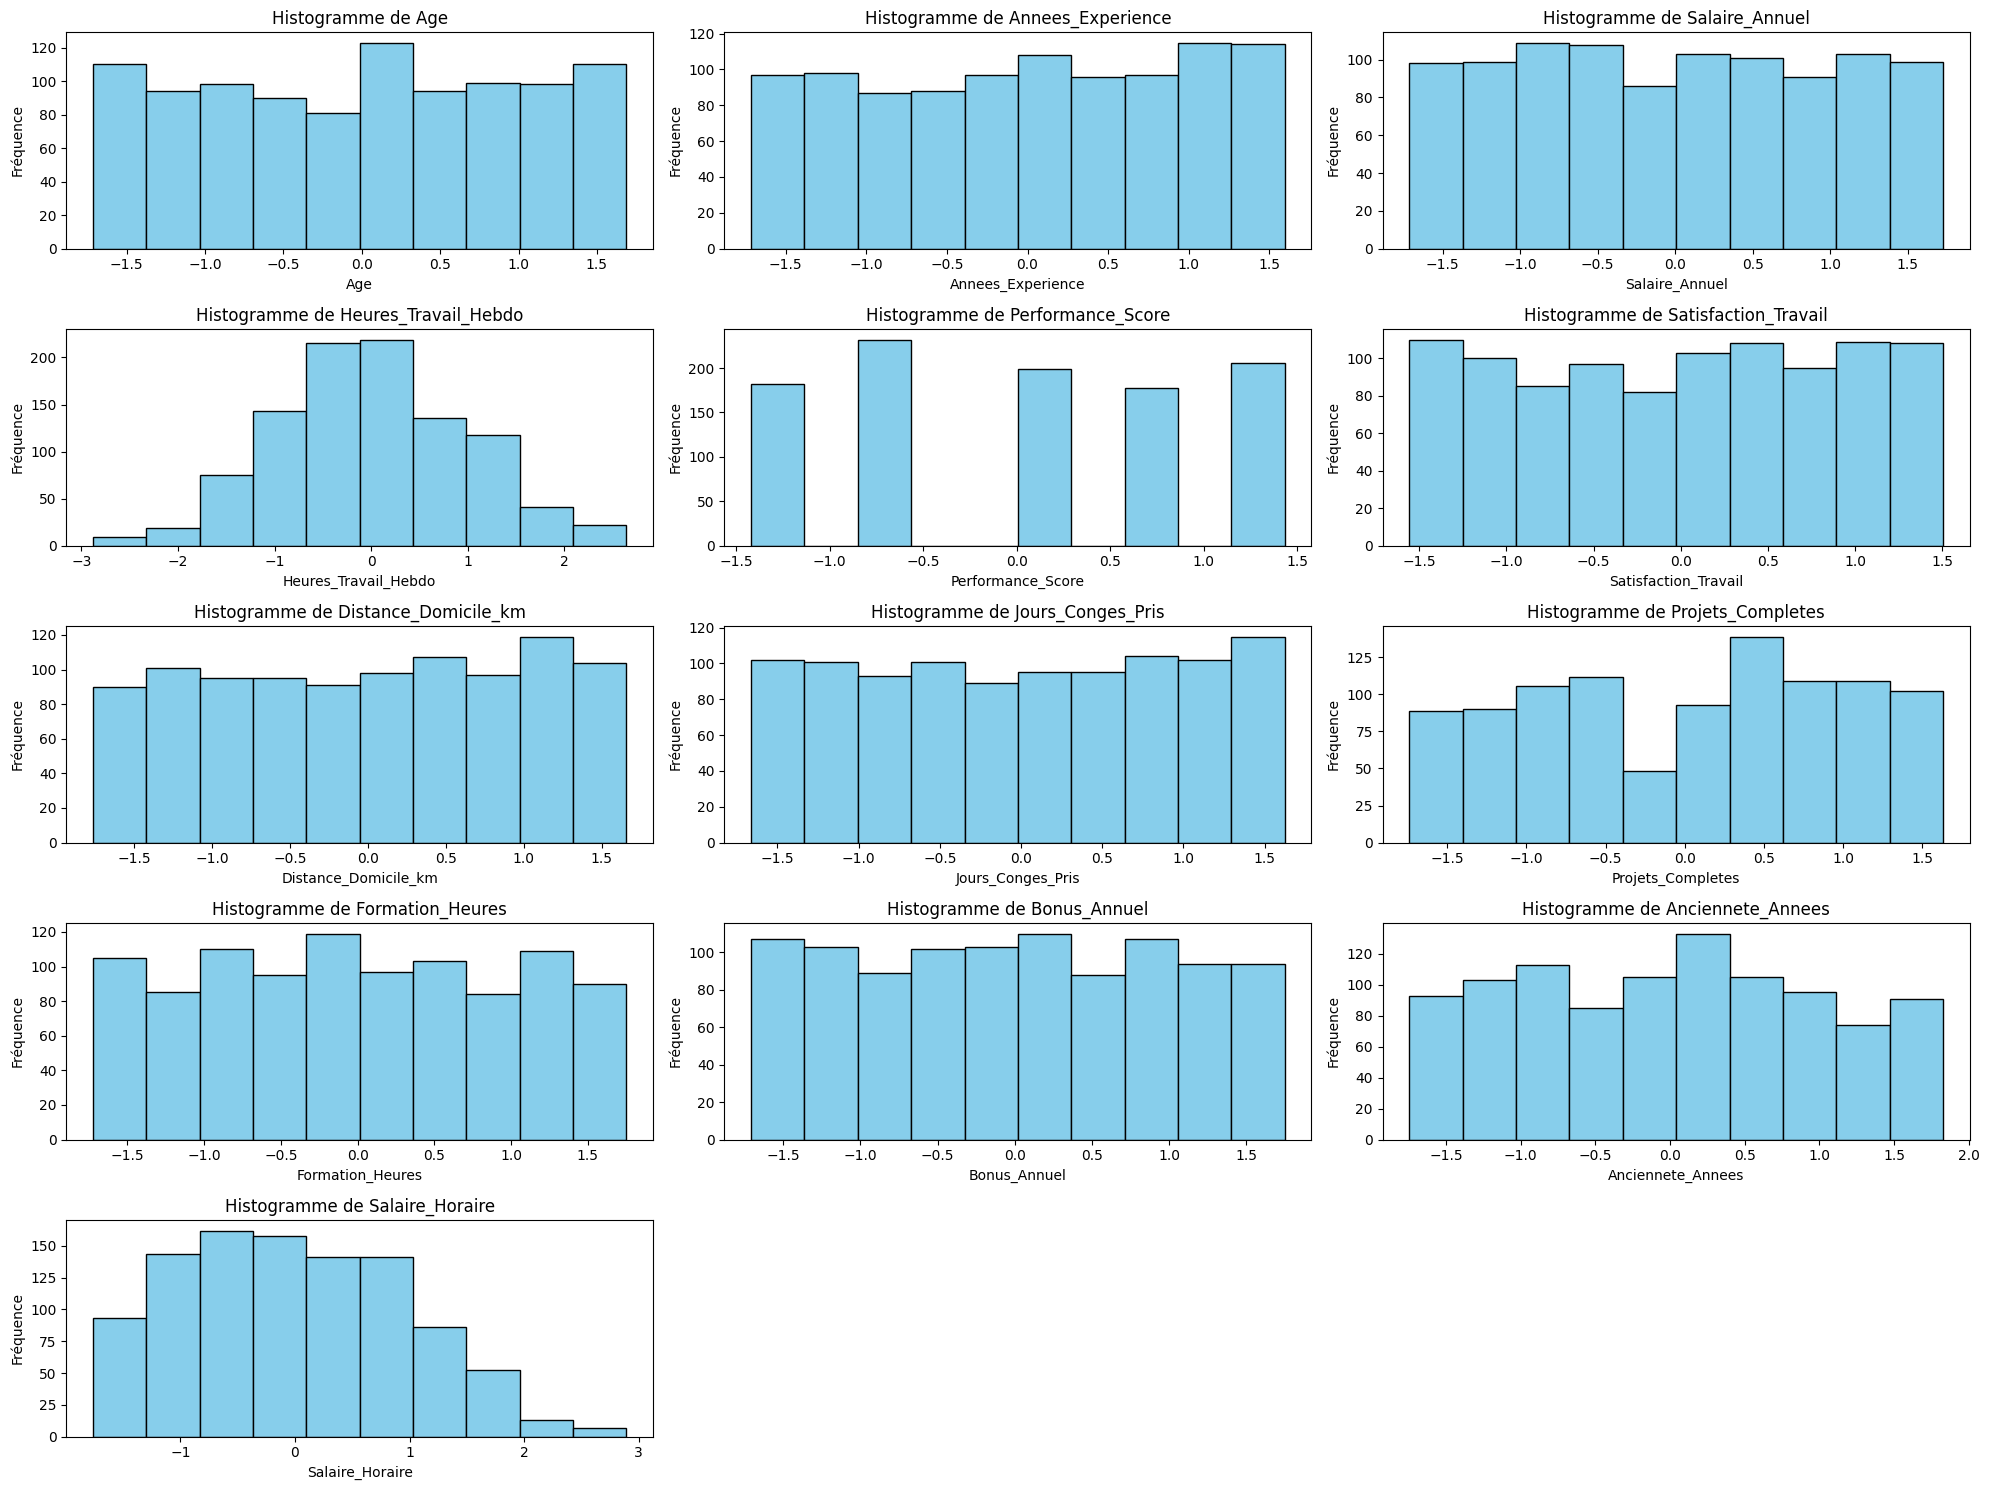

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 15))

# Adjust the number of rows and columns to fit all numeric columns
num_columns = len(numerical_cols)
num_rows = (num_columns + 2) // 3  # Calculate the number of rows needed

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, 3, i)  # Adjust the grid size
    plt.hist(df[col], bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Histogramme de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()

# Afficher les histogrammes
plt.show()

# data preparation

In [137]:
df.head()

,Nom_Departement,Age,Genre,Niveau_Education,Annees_Experience,Salaire_Annuel,Heures_Travail_Hebdo,Performance_Score,Satisfaction_Travail,Distance_Domicile_km,Jours_Conges_Pris,Projets_Completes,Formation_Heures,Bonus_Annuel,Anciennete_Annees,Salaire_Horaire
0,Marketing,-0.013290,H,Master,-0.801165,1.505881,-0.268905,-0.706611,-0.536256,1.169565,0.944398,-0.053912,-0.214742,-1.132593,-1.229306,1.476798
1,Finance,-0.094327,F,Licence,1.024072,-1.300065,-0.608080,1.432474,-0.196208,-1.240037,0.264404,0.320479,-1.444250,-1.395137,0.993168,-1.103754
2,Ventes,-1.309880,H,Master,1.480381,1.651047,-0.029488,-0.706611,-1.556400,-1.484490,0.604401,-1.738672,0.593220,1.222684,-0.872122,1.478180
3,Finance,-1.309880,F,Bac,1.024072,-0.442970,0.289735,0.006417,-1.556400,-1.344803,1.284395,-0.615499,0.136546,1.436045,0.199427,-0.529607
4,Finance,-1.471954,F,Bac,1.366304,-1.505585,1.067841,-0.706611,-1.216352,-0.820976,0.717733,1.256456,-0.847060,1.131590,0.993168,-1.571501


#### Encodage des variables catégorielles ['Nom_Departement', 'Genre', "Niveau_Education"]

In [138]:
label_encoder = LabelEncoder()

categorical_columns = ['Nom_Departement', 'Genre', "Niveau_Education"]
for col in categorical_columns:
	df[col] = label_encoder.fit_transform(df[col])

In [139]:
df.head()

,Nom_Departement,Age,Genre,Niveau_Education,Annees_Experience,Salaire_Annuel,Heures_Travail_Hebdo,Performance_Score,Satisfaction_Travail,Distance_Domicile_km,Jours_Conges_Pris,Projets_Completes,Formation_Heures,Bonus_Annuel,Anciennete_Annees,Salaire_Horaire
0,2,-0.013290,2,3,-0.801165,1.505881,-0.268905,-0.706611,-0.536256,1.169565,0.944398,-0.053912,-0.214742,-1.132593,-1.229306,1.476798
1,0,-0.094327,1,2,1.024072,-1.300065,-0.608080,1.432474,-0.196208,-1.240037,0.264404,0.320479,-1.444250,-1.395137,0.993168,-1.103754
2,5,-1.309880,2,3,1.480381,1.651047,-0.029488,-0.706611,-1.556400,-1.484490,0.604401,-1.738672,0.593220,1.222684,-0.872122,1.478180
3,0,-1.309880,1,0,1.024072,-0.442970,0.289735,0.006417,-1.556400,-1.344803,1.284395,-0.615499,0.136546,1.436045,0.199427,-0.529607
4,0,-1.471954,1,0,1.366304,-1.505585,1.067841,-0.706611,-1.216352,-0.820976,0.717733,1.256456,-0.847060,1.131590,0.993168,-1.571501


#### Séparation des features et de la variable cible

In [140]:
X = df.drop("Salaire_Annuel", axis=1) #.to_numpy()
y = df["Salaire_Annuel"]



#### Normalisation des données [X_train, X_test, y_train, y_test]

In [141]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [142]:
X_train.shape

(797, 15)

In [143]:
# # Normalisation des données
# scaler = StandardScaler()

# # Normalisation de X_train et X_test
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# y_train = scaler.fit_transform(y_train.values.reshape(-1, 1))
# y_test = scaler.transform(y_test.values.reshape(-1, 1))

#  ***deep learning***

#### Création du modèle de deep learning

In [144]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1

In [145]:
# Define the Keras Sequential model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # Explicit input layer
    layers.Dense(64, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(32, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(16, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(1)
])

In [146]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Compilation du modèle

In [147]:
#from tensorflow.keras.optimizers import Adam   # SGD # RMSprop # Adagrad # Adam
#algor = Adam(learning_rate=0.001)

model.compile(optimizer="Adam", loss="mse", metrics=["mae"]) # mse: Mean Squared Error, mae: Mean Absolute Error

#### Entraînement du modèle

In [148]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = "val_loss", patience = 50, restore_best_weights = True)


history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.9194 - mae: 0.8930 - val_loss: 5.6176 - val_mae: 0.8608
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.4193 - mae: 0.7740 - val_loss: 5.2696 - val_mae: 0.7888
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.1141 - mae: 0.7093 - val_loss: 4.9439 - val_mae: 0.7124
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7841 - mae: 0.6404 - val_loss: 4.5838 - val_mae: 0.6106
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4382 - mae: 0.5334 - val_loss: 4.2227 - val_mae: 0.4857
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1194 - mae: 0.4274 - val_loss: 3.8905 - val_mae: 0.3522
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8186 - mae: 0.3105 - val_loss: 3.6270 - val_mae: 0.2481
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5730 - mae: 0.2262 - val_loss: 3.4133 - val_mae: 0.1956
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

#### Évaluation du modèle

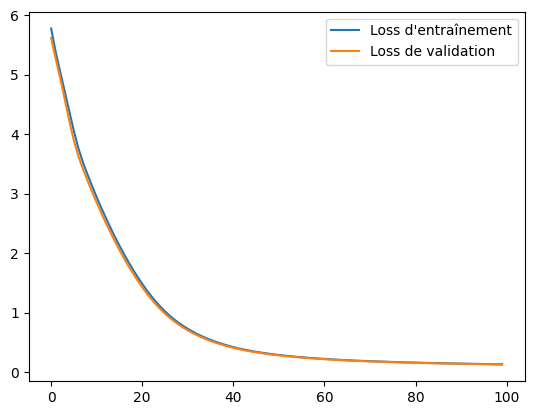

In [149]:
plt.plot(history.history['loss'], label="Loss d'entraînement")
plt.plot(history.history['val_loss'], label="Loss de validation")
plt.legend()
plt.show()

#### Évaluation sur les données de test

In [150]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Erreur quadratique moyenne (MSE) : {loss}")
print(f"Erreur absolue moyenne (MAE) : {mae}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1312 - mae: 0.0698 
Erreur quadratique moyenne (MSE) : 0.13095764815807343
Erreur absolue moyenne (MAE) : 0.06922322511672974


### utilisation de méthode predict

In [151]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


# Visualisation des résultats

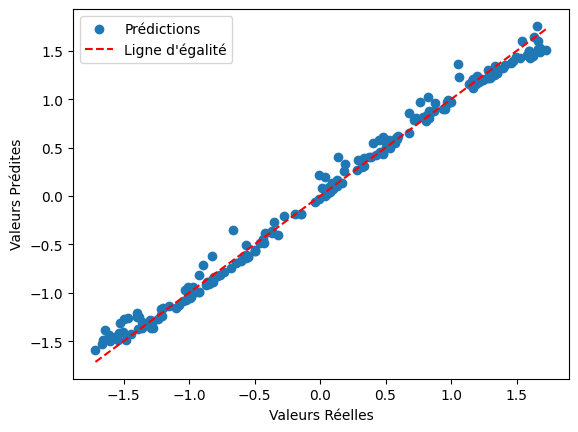

In [152]:
plt.scatter(y_test, y_pred, label='Prédictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ligne d\'égalité')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.legend()
plt.show()